# Aggregated ACF & PACF Across All Subjects (Pirate Pain)

This notebook computes **aggregated Autocorrelation (ACF)** and **Partial Autocorrelation (PACF)** for:

- all `joint_*` columns (excluding `joint_30`)
- the `pain_survey_*` columns

Instead of inspecting one subject (one `sample_index`) at a time, we
1. Compute the ACF combining all users together.
2. Use this "average" ACF to compute the PACF.
3. Plot the ACF/PACF.

Then, we compute the average of the periodograms of all users for each of previously said columns.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import acf, pacf

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True


In [2]:
# Paths to your CSV files (update if needed)
train_path = "kaggle/input/pirate-pain-dataset-feature-engineering/pirate_pain_train.csv"
test_path  = "kaggle/input/pirate-pain-dataset-feature-engineering/pirate_pain_test.csv"  # not used here but kept for completeness

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)
df_test['sample_index'] = df_test['sample_index'] + df_train['sample_index'].nunique()

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

df_total = pd.concat([df_train, df_test], axis=0)
df_total.head()


Train shape: (105760, 40)
Test shape: (211840, 40)


,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
0,0,0,2,0,2,1,two,two,two,1.094705,...,3.499558e-06,1.945042e-06,0.000004,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0.5
1,0,1,2,2,2,2,two,two,two,1.135183,...,3.976952e-07,6.765107e-07,0.000006,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0.5
2,0,2,2,0,2,2,two,two,two,1.080745,...,1.533820e-07,1.698525e-07,0.000001,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0.5
3,0,3,2,2,2,2,two,two,two,0.938017,...,1.006865e-05,5.511079e-07,0.000002,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0.5
4,0,4,2,2,2,2,two,two,two,1.090185,...,4.437266e-06,1.735459e-07,0.000002,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0.5


In [3]:
N_USERS = df_total['sample_index'].nunique()
print(N_USERS)  # Print the number of unique users

1985


In [4]:
# Key columns (adapt names here if different in your data)
ID_COL     = "sample_index"
TIME_COL   = "time"

# All joint_* columns except joint_30
pain_cols = [c for c in df_train.columns if c.startswith("pain_survey_")]
joint_cols = [c for c in df_train.columns if c.startswith("joint_") and c != "joint_30"]

series_cols = joint_cols + pain_cols

print("Number of joints (excluding joint_30):", len(joint_cols))
print("Example joint columns:", joint_cols[:10])
print("All series columns to analyze:", series_cols)

# Ensure data are sorted by (sample_index, time)
df_total = df_total.sort_values([ID_COL, TIME_COL]).reset_index(drop=True)

unique_ids = df_total[ID_COL].unique()
print("Number of unique subjects (sample_index):", len(unique_ids))

df_total = df_total[[ID_COL, TIME_COL] + series_cols]
df_total.head()

Number of joints (excluding joint_30): 30
Example joint columns: ['joint_00', 'joint_01', 'joint_02', 'joint_03', 'joint_04', 'joint_05', 'joint_06', 'joint_07', 'joint_08', 'joint_09']
All series columns to analyze: ['joint_00', 'joint_01', 'joint_02', 'joint_03', 'joint_04', 'joint_05', 'joint_06', 'joint_07', 'joint_08', 'joint_09', 'joint_10', 'joint_11', 'joint_12', 'joint_13', 'joint_14', 'joint_15', 'joint_16', 'joint_17', 'joint_18', 'joint_19', 'joint_20', 'joint_21', 'joint_22', 'joint_23', 'joint_24', 'joint_25', 'joint_26', 'joint_27', 'joint_28', 'joint_29', 'pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4']
Number of unique subjects (sample_index): 1985


,sample_index,time,joint_00,joint_01,joint_02,joint_03,joint_04,joint_05,joint_06,joint_07,...,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4
0,0,0,1.094705,0.985281,1.018302,1.010385,0.971717,1.022263,0.901755,0.999659,...,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815,2,0,2,1
1,0,1,1.135183,1.021175,0.994343,1.052364,0.999944,1.012395,0.923341,1.035850,...,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716,2,2,2,2
2,0,2,1.080745,0.962842,1.009588,0.977169,0.984740,1.019930,0.976567,1.072751,...,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105,2,0,2,2
3,0,3,0.938017,1.081592,0.998021,0.987283,0.924161,1.002642,0.830982,1.080755,...,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648,2,2,2,2
4,0,4,1.090185,1.032145,1.008710,0.963658,1.016291,1.031301,0.956008,0.988023,...,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328,2,2,2,2


In [5]:
df_total[series_cols] = df_total[series_cols] - df_total[series_cols].mean()
df_total.head()

,sample_index,time,joint_00,joint_01,joint_02,joint_03,joint_04,joint_05,joint_06,joint_07,...,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4
0,0,0,0.124256,0.011392,0.202706,0.194391,0.250291,0.271689,0.016049,0.127924,...,-0.000022,-0.000102,-0.023391,-0.045997,-0.024825,-0.033755,0.378501,-1.662037,0.343785,-0.66324
1,0,1,0.164734,0.047286,0.178747,0.236371,0.278518,0.261822,0.037635,0.164116,...,-0.000033,-0.000105,-0.027631,-0.059504,-0.038246,-0.047854,0.378501,0.337963,0.343785,0.33676
2,0,2,0.110295,-0.011046,0.193991,0.161175,0.263314,0.269356,0.090861,0.201017,...,-0.000031,-0.000103,-0.024758,-0.051394,-0.027526,-0.038465,0.378501,-1.662037,0.343785,0.33676
3,0,3,-0.032433,0.107704,0.182424,0.171290,0.202734,0.252068,-0.054724,0.209021,...,-0.000033,-0.000105,-0.029152,-0.052054,-0.023009,-0.036921,0.378501,0.337963,0.343785,0.33676
4,0,4,0.119735,0.058256,0.193113,0.147664,0.294864,0.280727,0.070302,0.116288,...,-0.000033,-0.000098,-0.035623,-0.056973,-0.018596,-0.036242,0.378501,0.337963,0.343785,0.33676


In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import levinson_durbin

def pooled_acf_pacf_all(df, column, max_lag):
    # Pre-group once
    groups = df.groupby("sample_index")

    # Collect all realizations
    series_list = [g[column].values for _, g in groups]

    # Compute autocovariances
    acov = np.zeros(max_lag + 1)
    for k in range(max_lag + 1):
        vals = [np.mean((x - x.mean())[:-k] * (x - x.mean())[k:])
                for x in series_list if len(x) > k] if k > 0 \
                else [np.mean((x - x.mean())**2) for x in series_list]
        acov[k] = np.mean(vals)

    # Fast Durbin–Levinson for PACF
    _, _, pacf, _, _ = levinson_durbin(acov, nlags=max_lag, isacov=True)

    acf = acov / acov[0]  # Normalize

    return acf, pacf

In [7]:
def plot_aggregated_acf_pacf(lags, acf, pacf, col_name, n_users):
    """Plot mean ACF/PACF with ±2·std bands."""
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    # Approx. 95% cutoff for ACF/PACF
    crit = 1.96 / np.sqrt(160*n_users)
    
    # ACF
    axes[0].axhline(0, linewidth=1)
    axes[0].stem(lags, acf, basefmt=" ")
    axes[0].axhline(crit,  linestyle="--", color="red")
    axes[0].axhline(-crit, linestyle="--", color="red")
    axes[0].set_ylabel("Lag")
    axes[0].set_ylabel("ACF")
    axes[0].set_title(f"Aggregated ACF for {col_name} (n_subjects={n_users})")
    
    # PACF
    axes[1].axhline(0, linewidth=1)
    axes[1].stem(lags, pacf, basefmt=" ")
    axes[1].axhline(crit,  linestyle="--", color="red")
    axes[1].axhline(-crit, linestyle="--", color="red")
    axes[1].set_xlabel("Lag")
    axes[1].set_ylabel("PACF")
    axes[1].set_title(f"Aggregated PACF for {col_name} (n_subjects={n_users})")
    
    fig.tight_layout()
    plt.show()


In [8]:
def seasonal_diff_df(df, lag, features=None):
    """
    df: dataframe with user_id, timestamp columns
    lag: seasonal lag (e.g., 24, 7*24, etc.)
    features: optional list of features to difference
    """
    if features is None:
        features = [c for c in df.columns if c not in ["sample_index", "time"]]

    # Apply seasonal differencing by user
    diffed = df.groupby("sample_index")[features].diff(lag)

    # Put back identifying columns
    out = df[["sample_index", "time"]].copy()
    out[features] = diffed
    return out


Processing column: joint_00


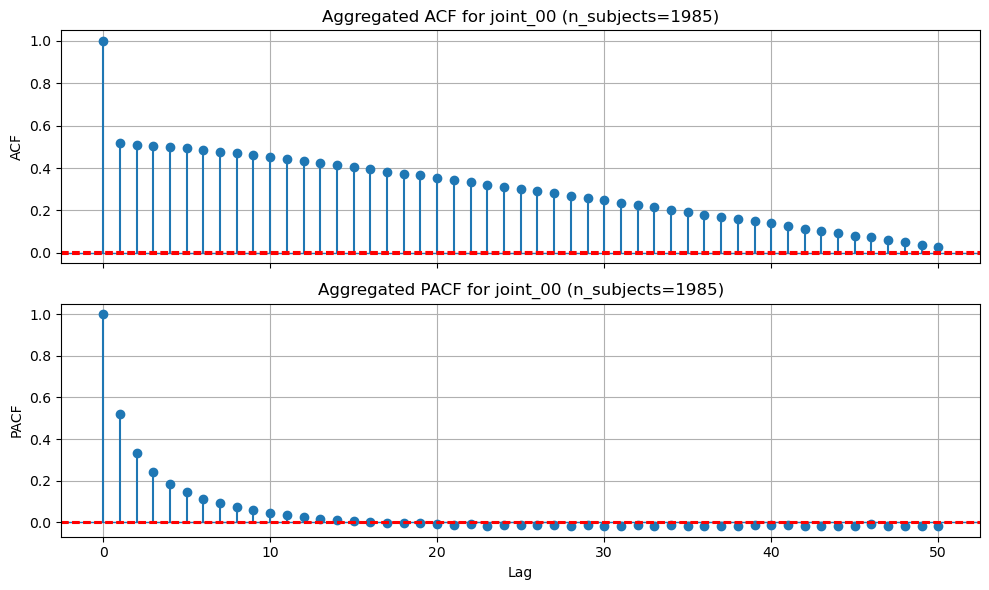


Processing column: joint_01


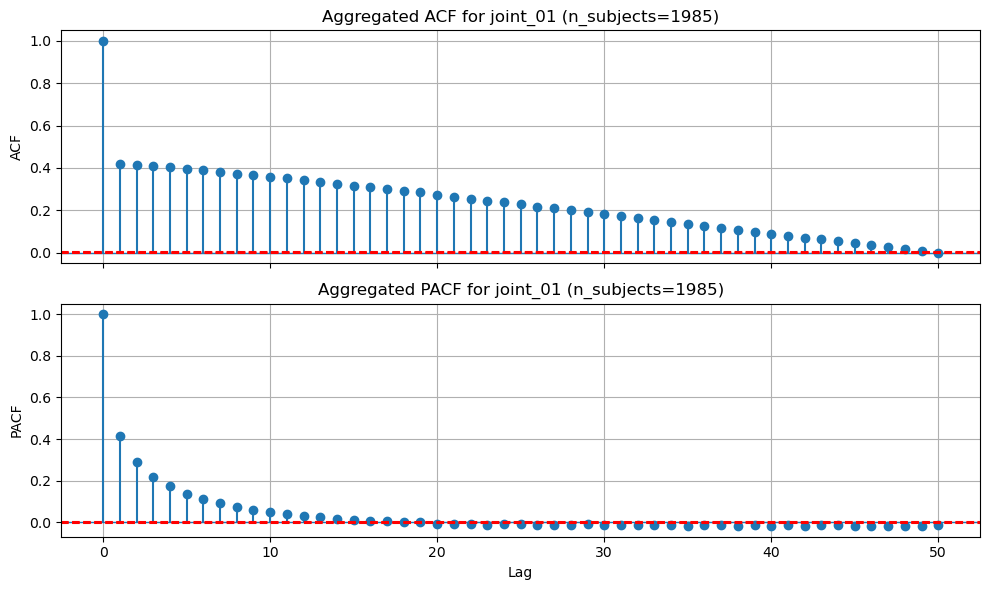


Processing column: joint_02


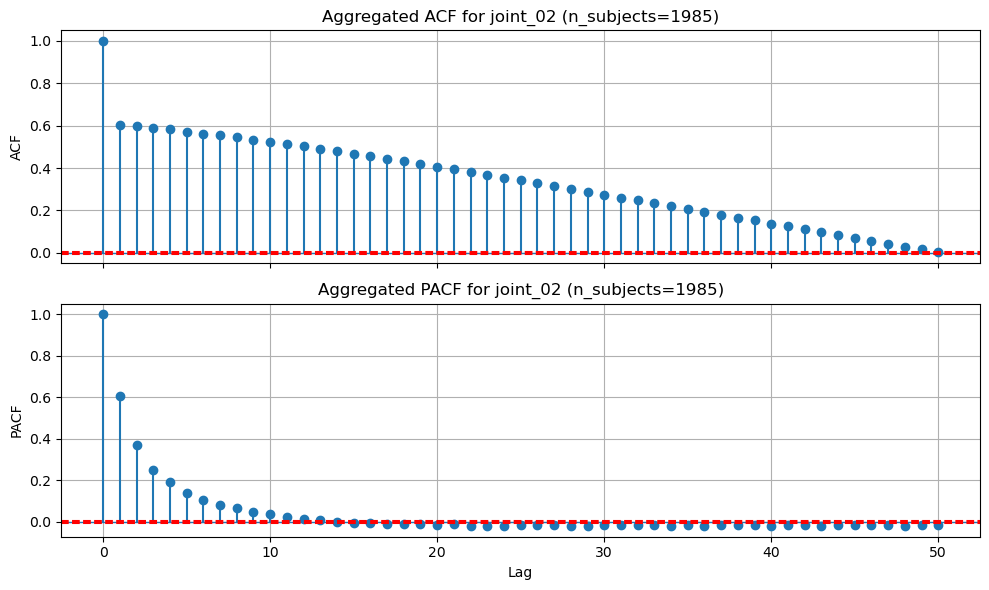


Processing column: joint_03


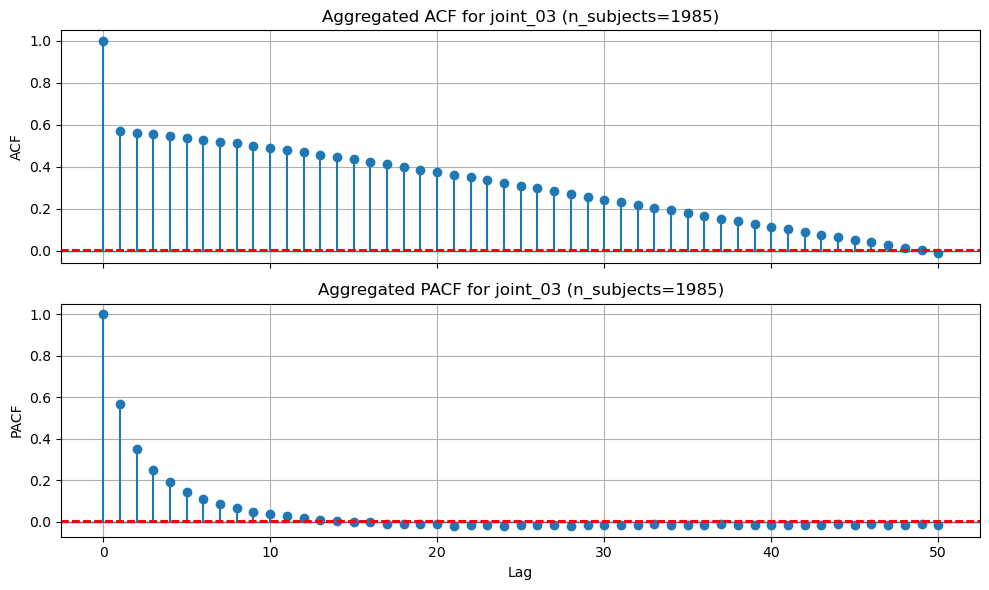


Processing column: joint_04


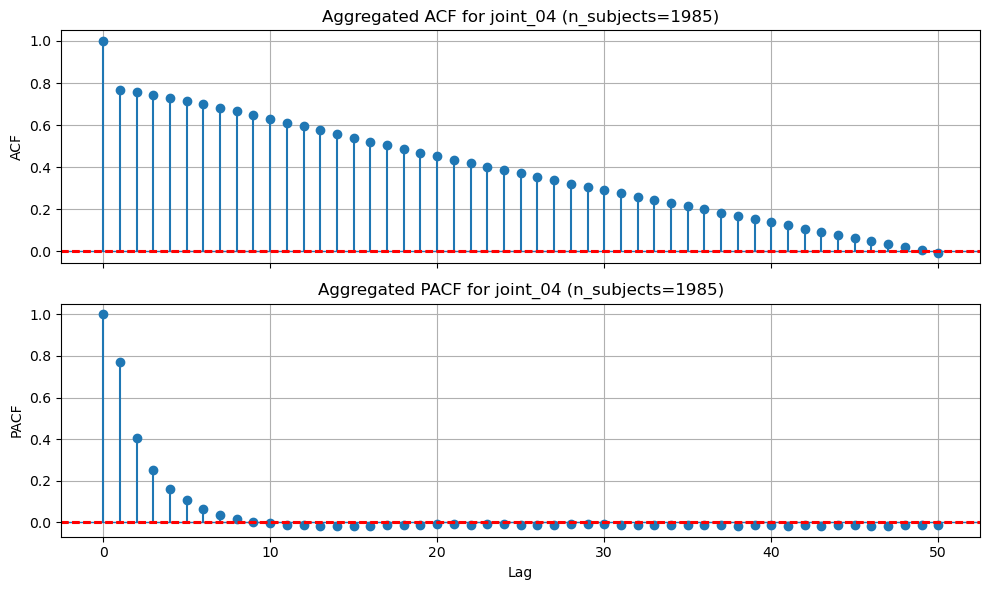


Processing column: joint_05


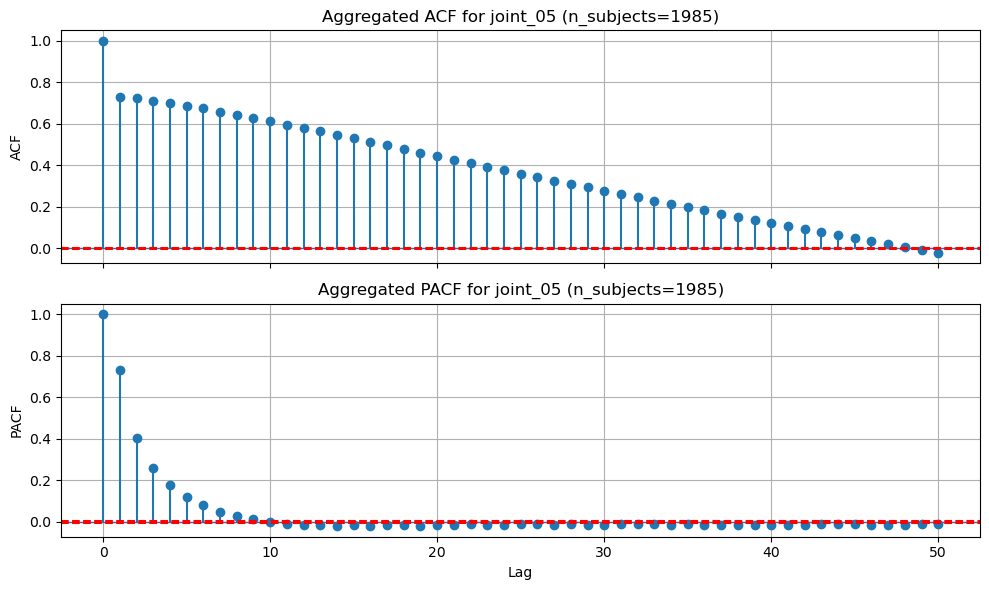


Processing column: joint_06


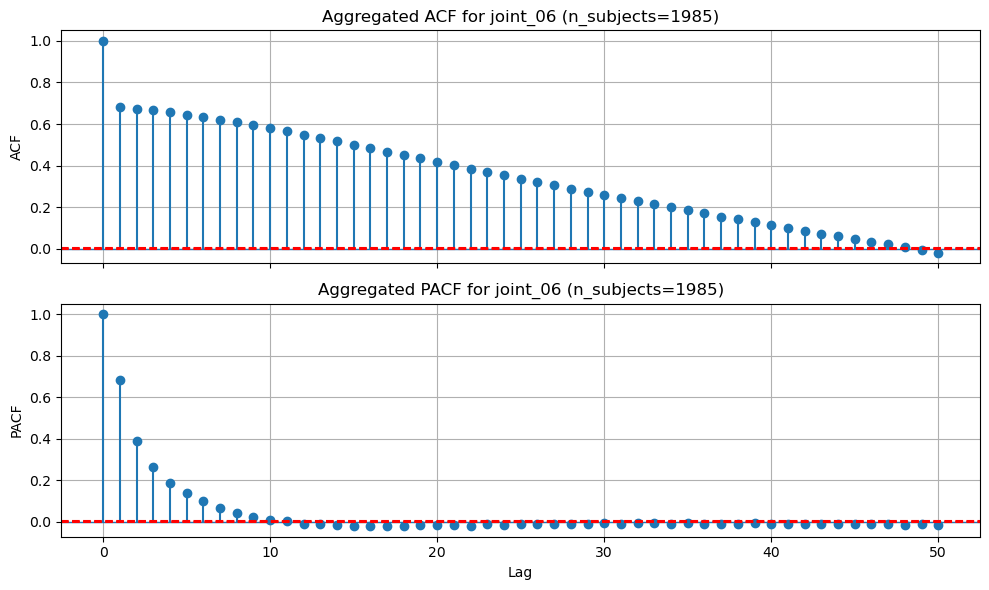


Processing column: joint_07


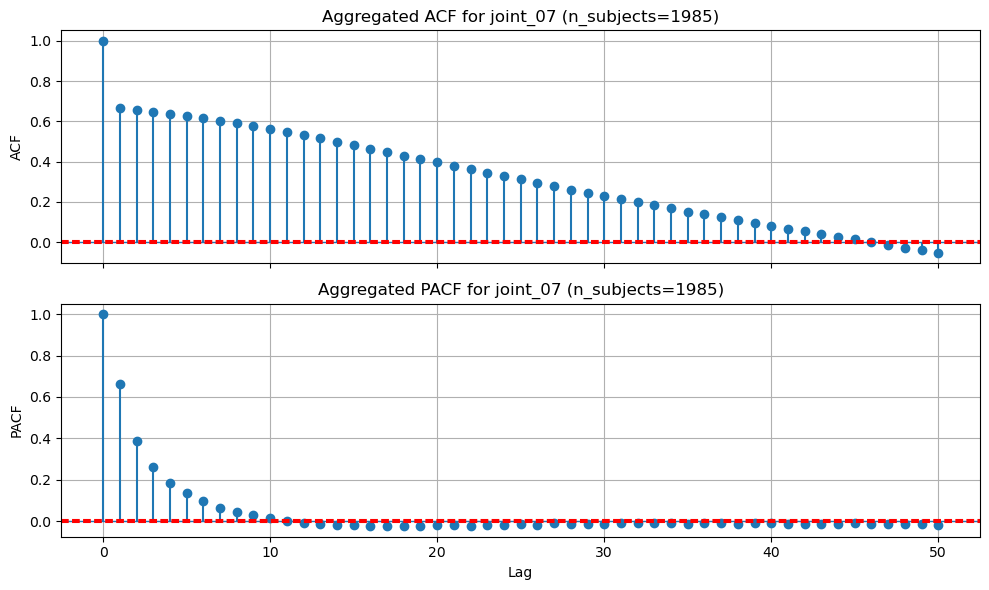


Processing column: joint_08


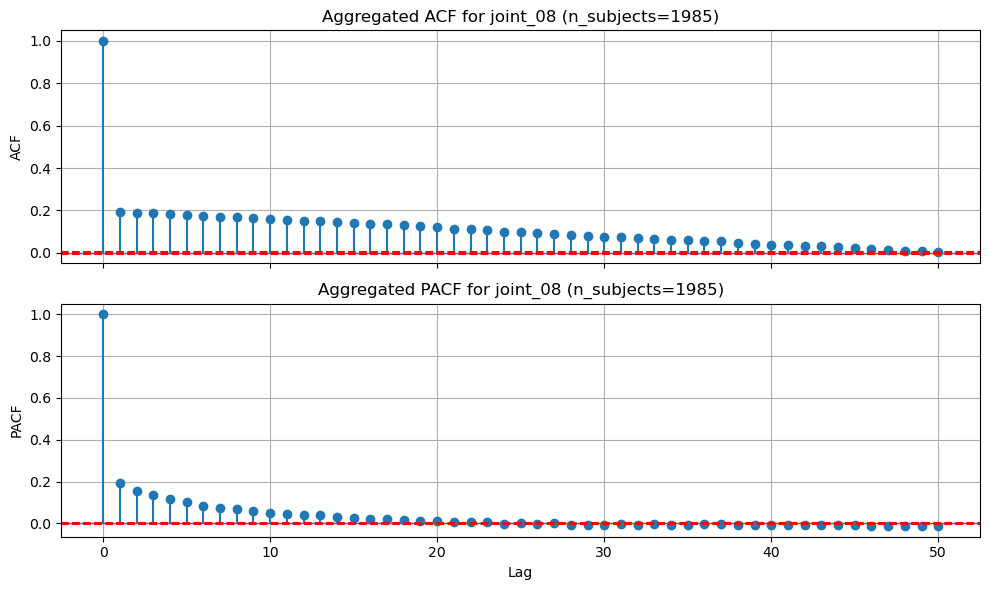


Processing column: joint_09


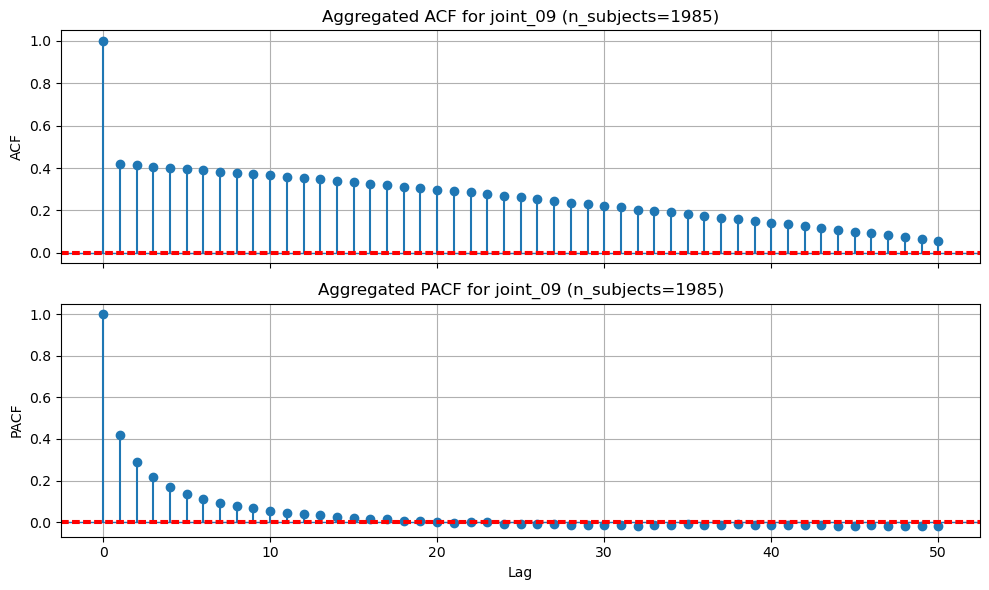


Processing column: joint_10


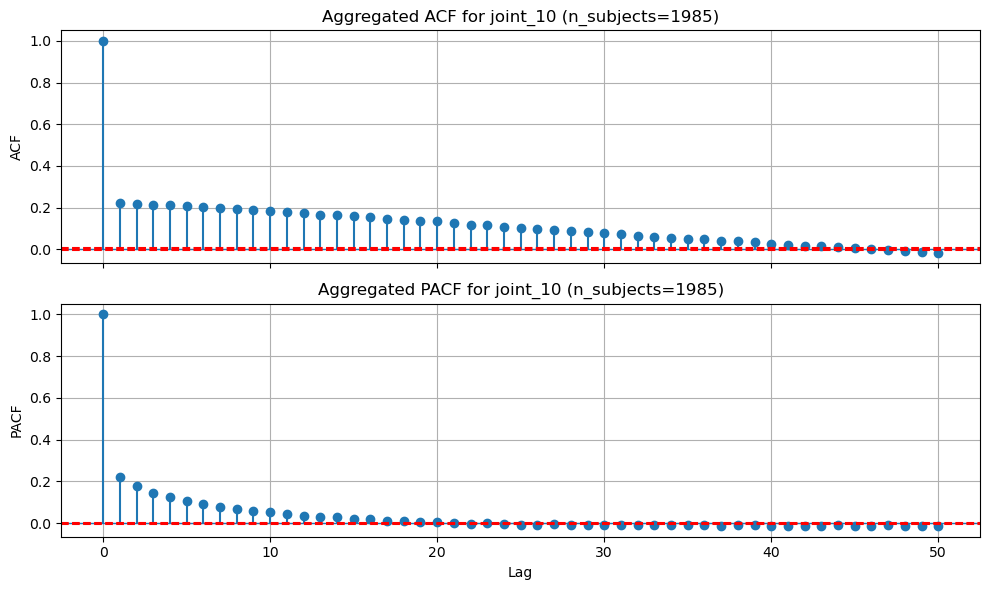


Processing column: joint_11


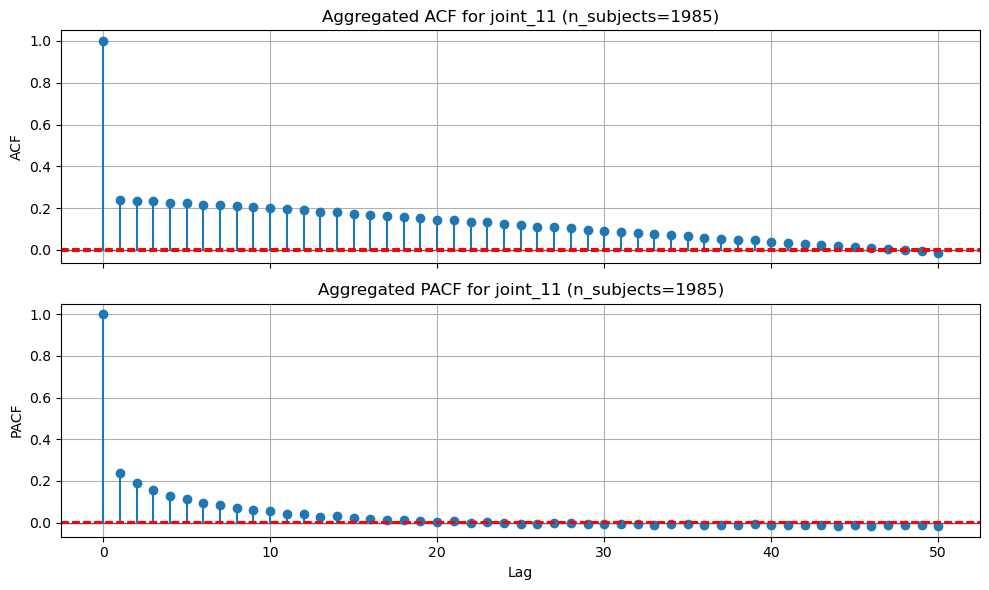


Processing column: joint_12


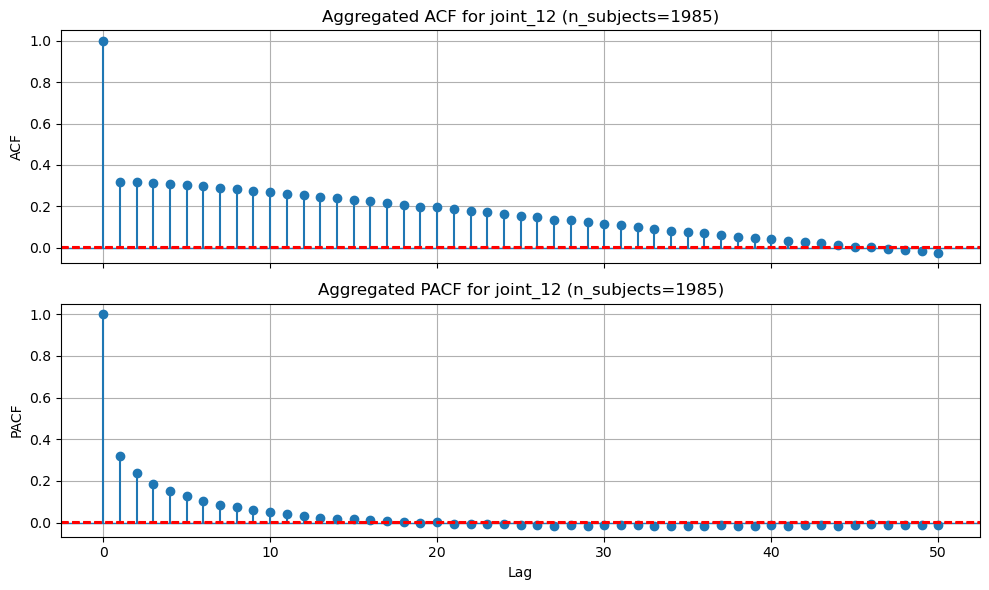


Processing column: joint_13


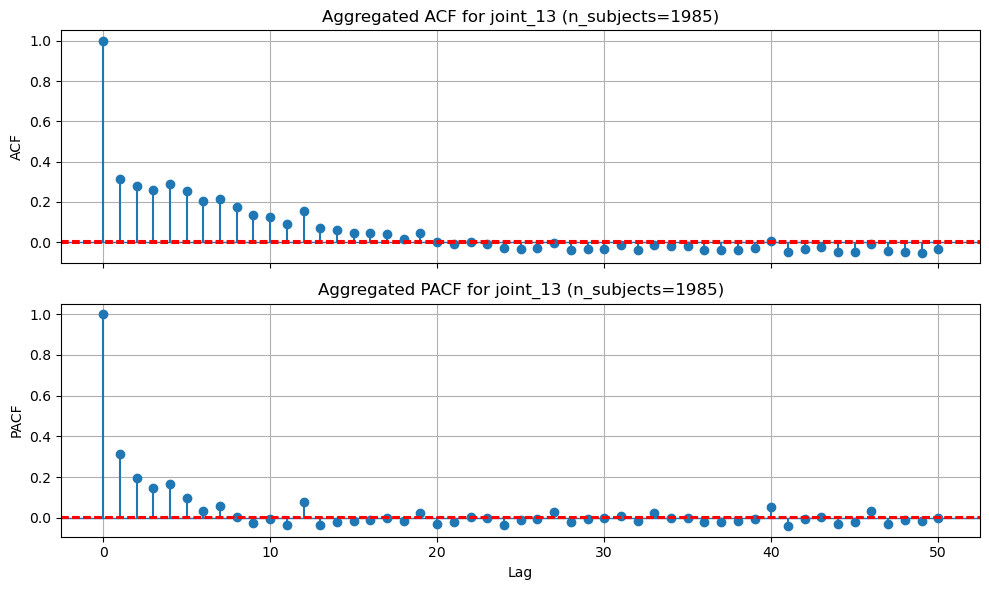


Processing column: joint_14


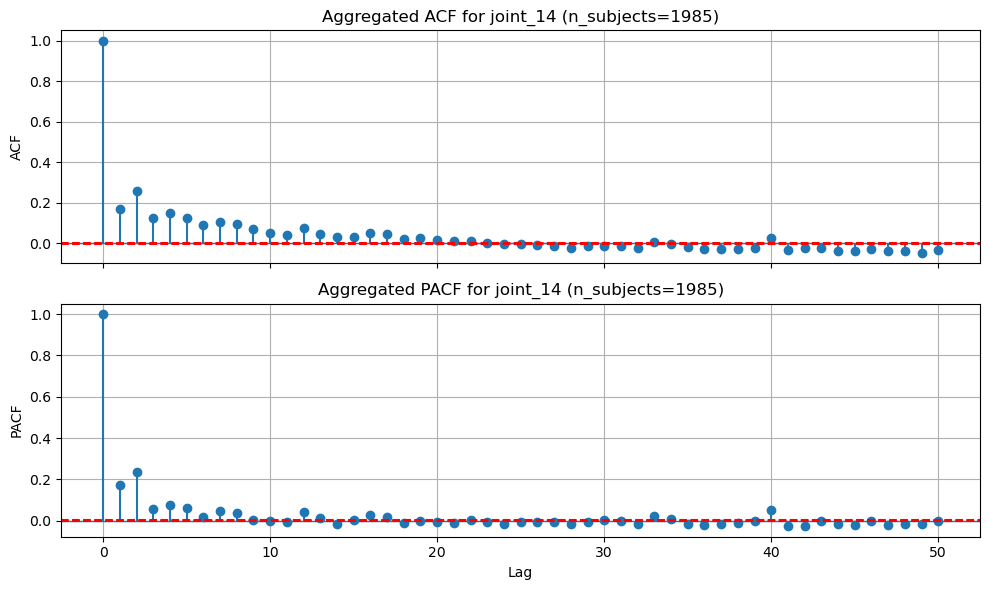


Processing column: joint_15


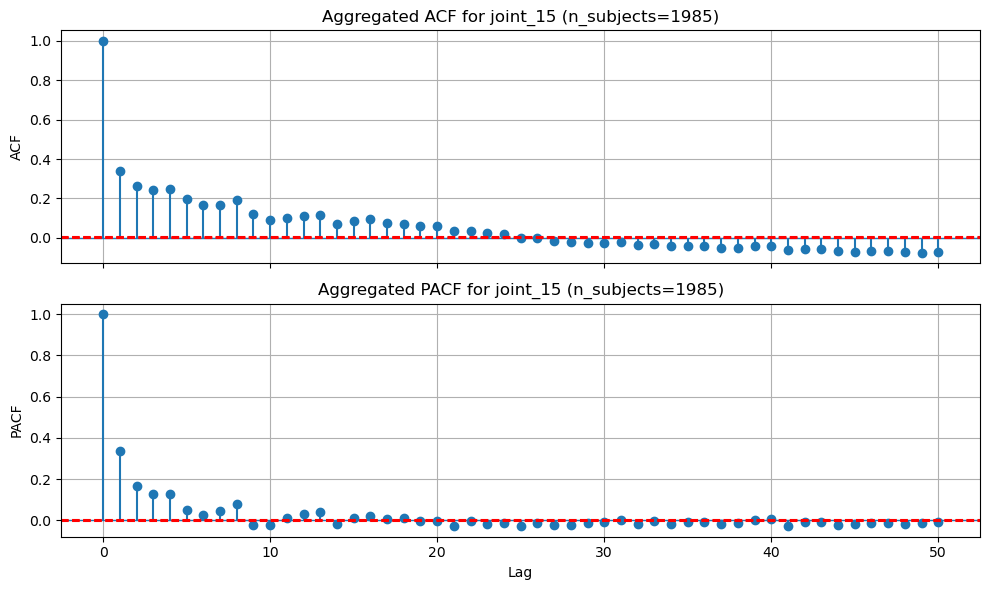


Processing column: joint_16


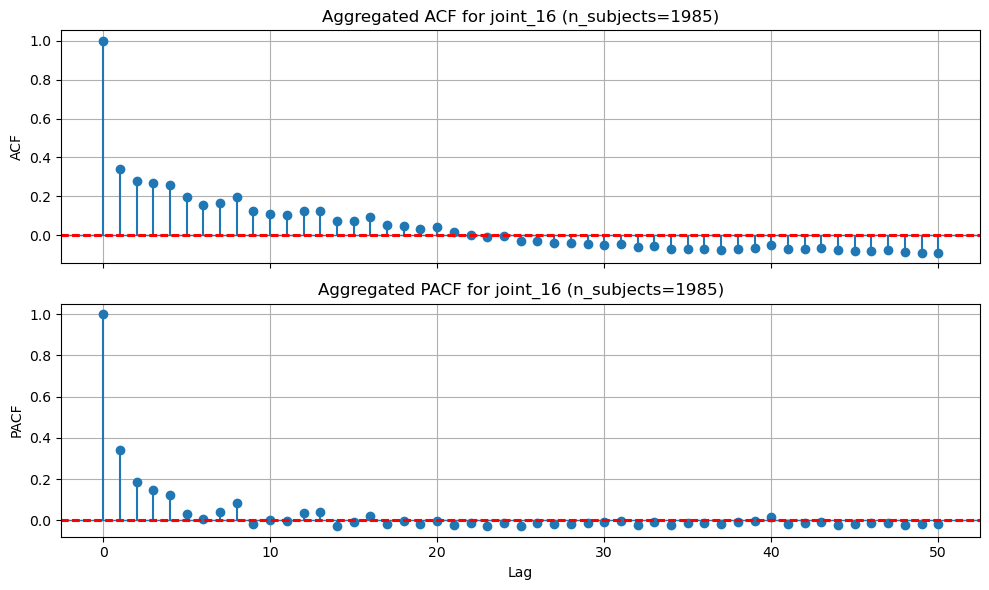


Processing column: joint_17


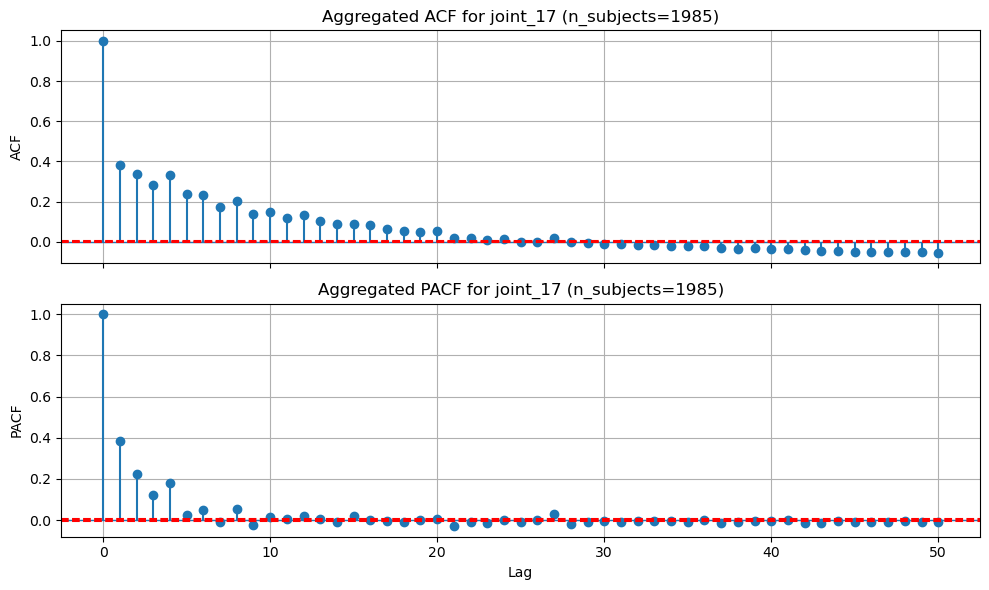


Processing column: joint_18


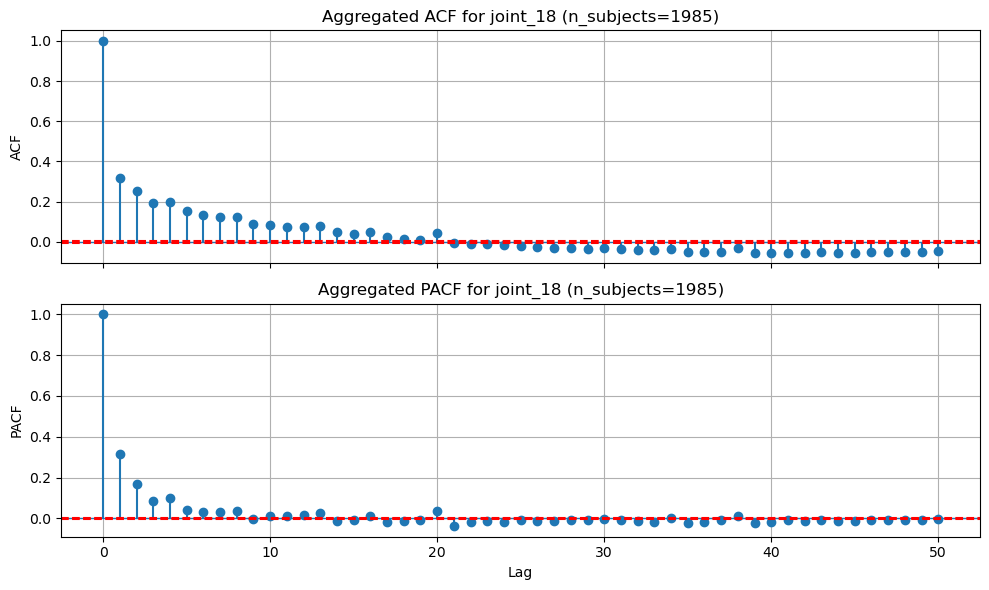


Processing column: joint_19


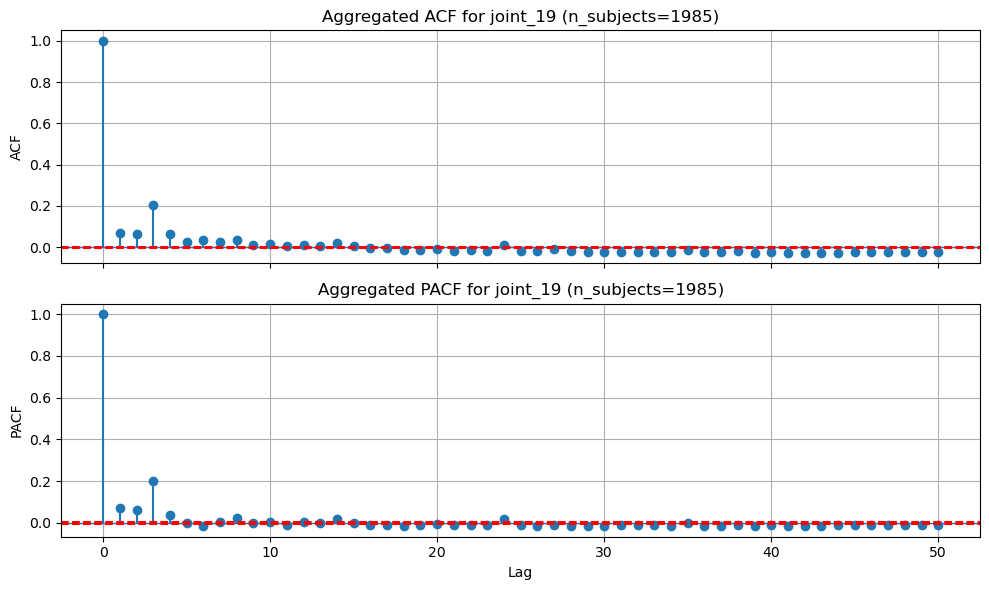


Processing column: joint_20


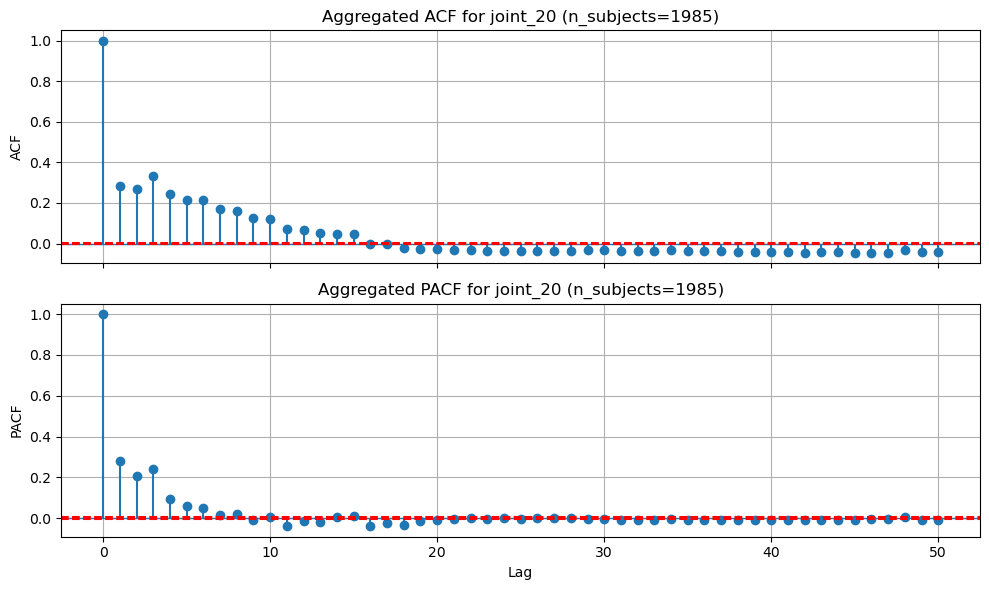


Processing column: joint_21


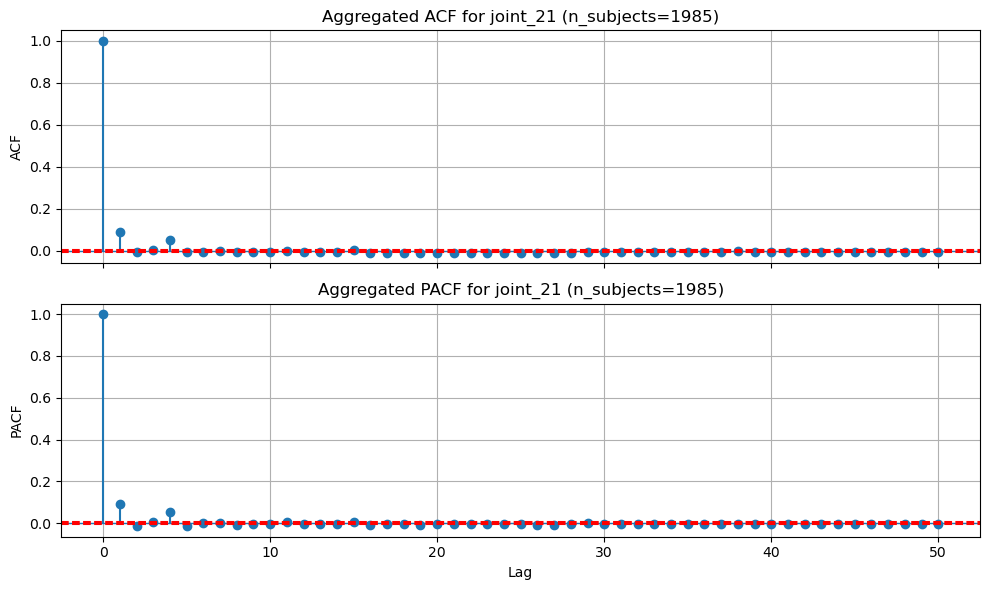


Processing column: joint_22


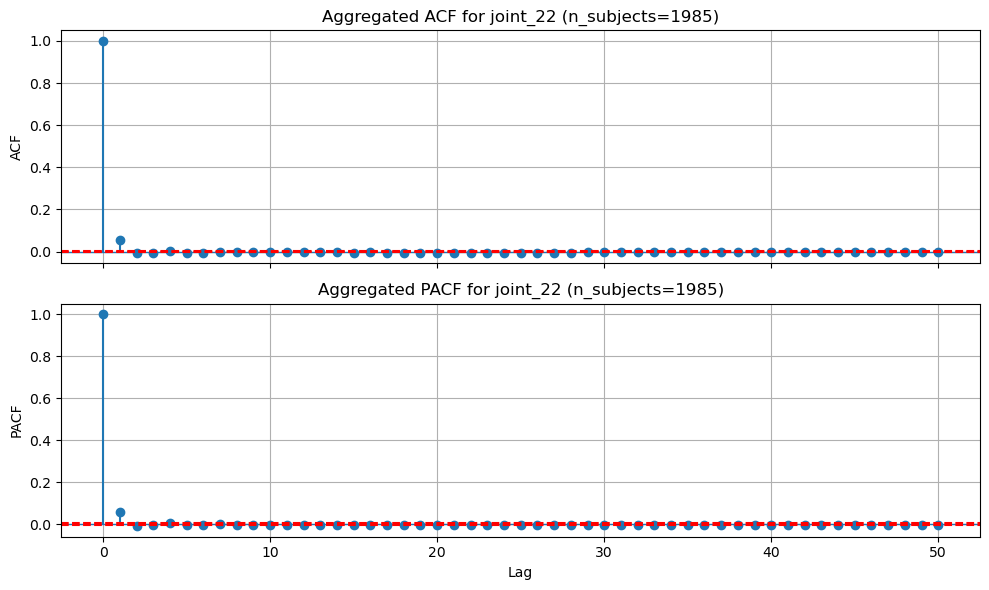


Processing column: joint_23


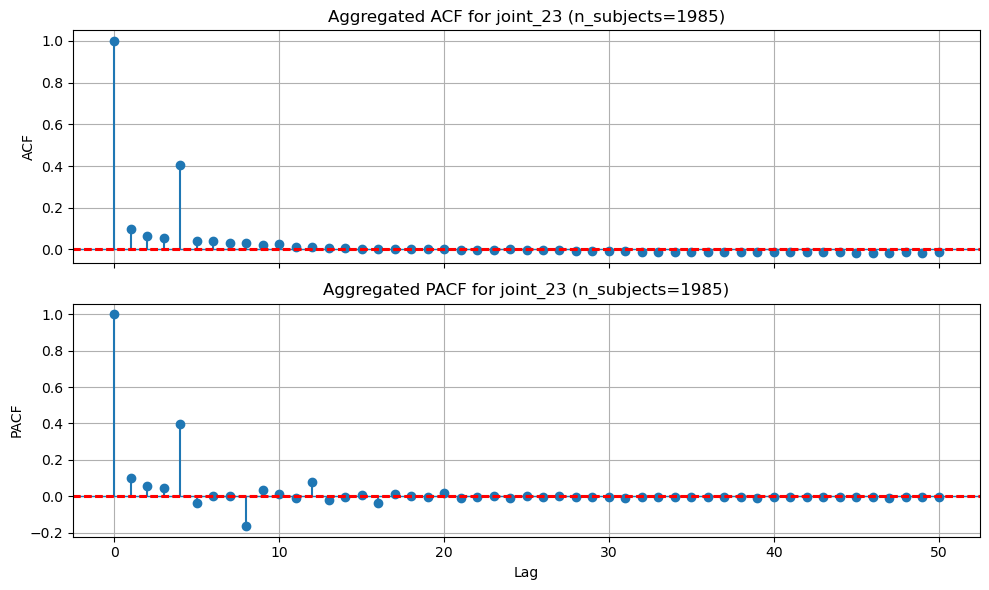


Processing column: joint_24


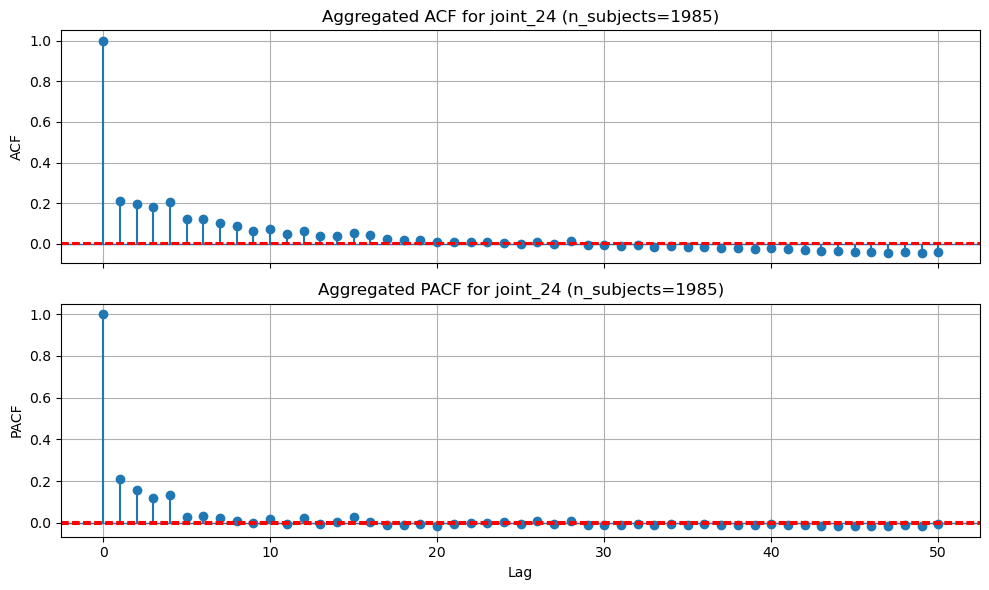


Processing column: joint_25


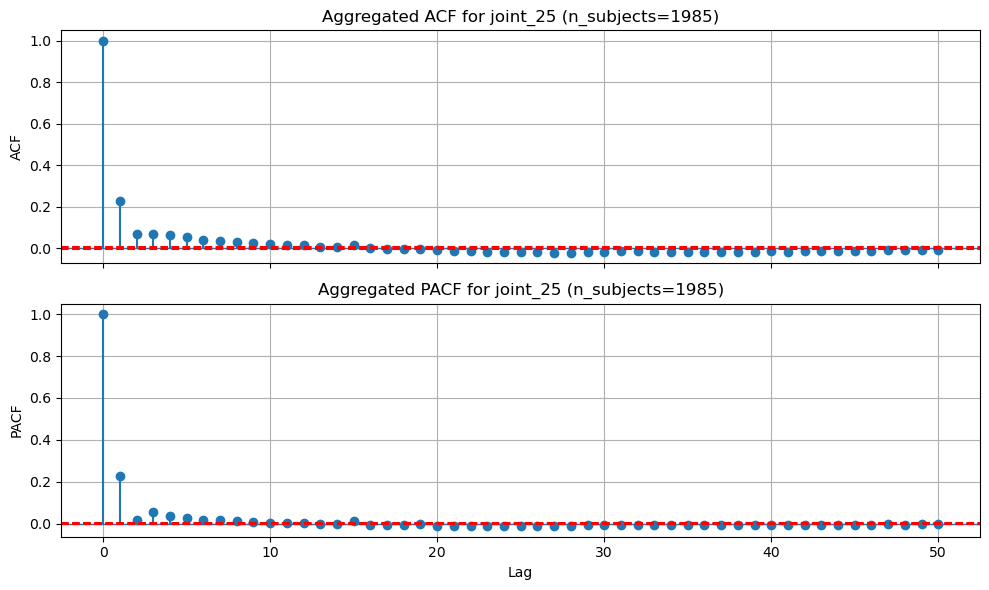


Processing column: joint_26


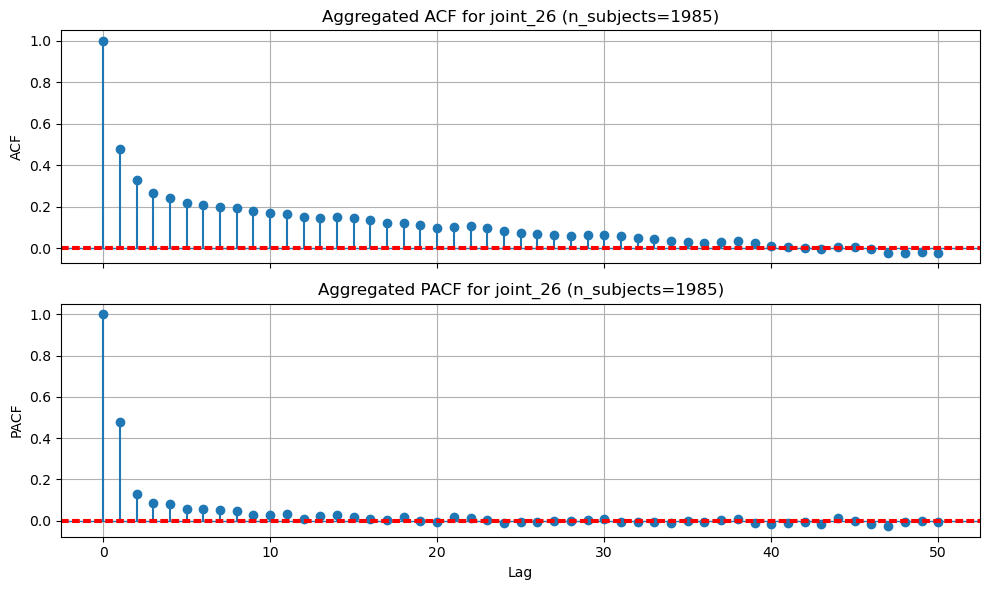


Processing column: joint_27


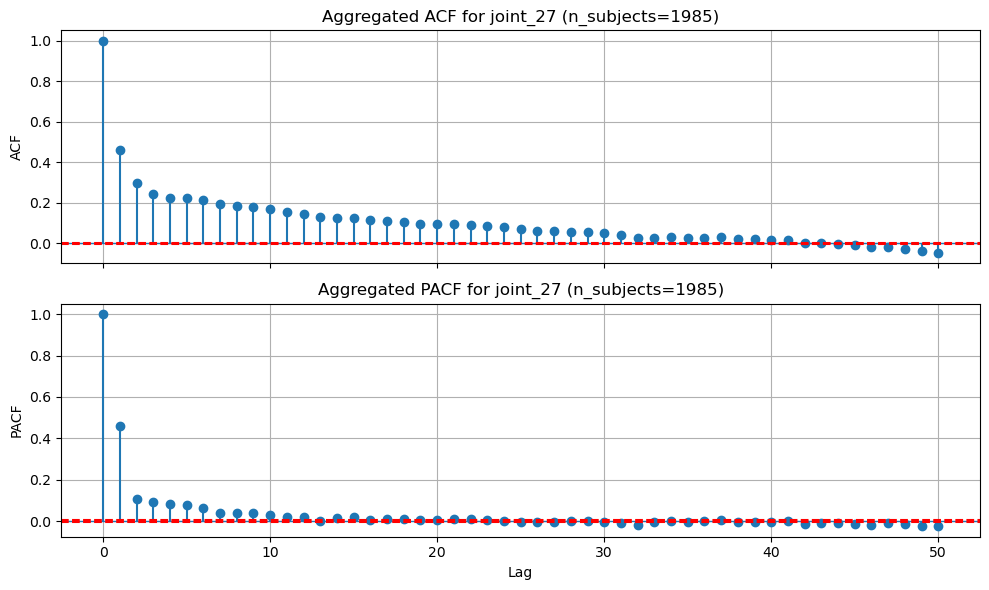


Processing column: joint_28


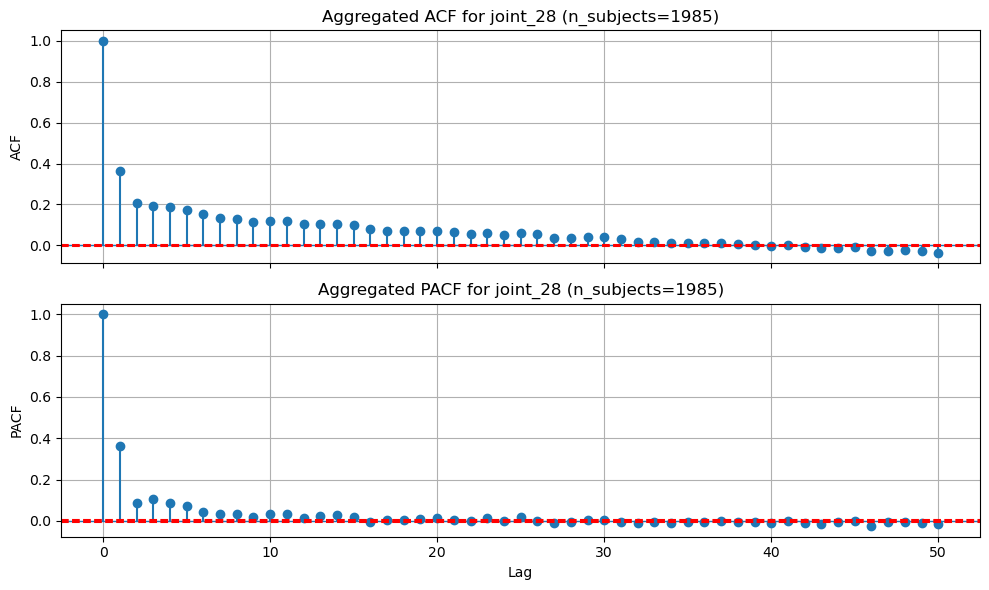


Processing column: joint_29


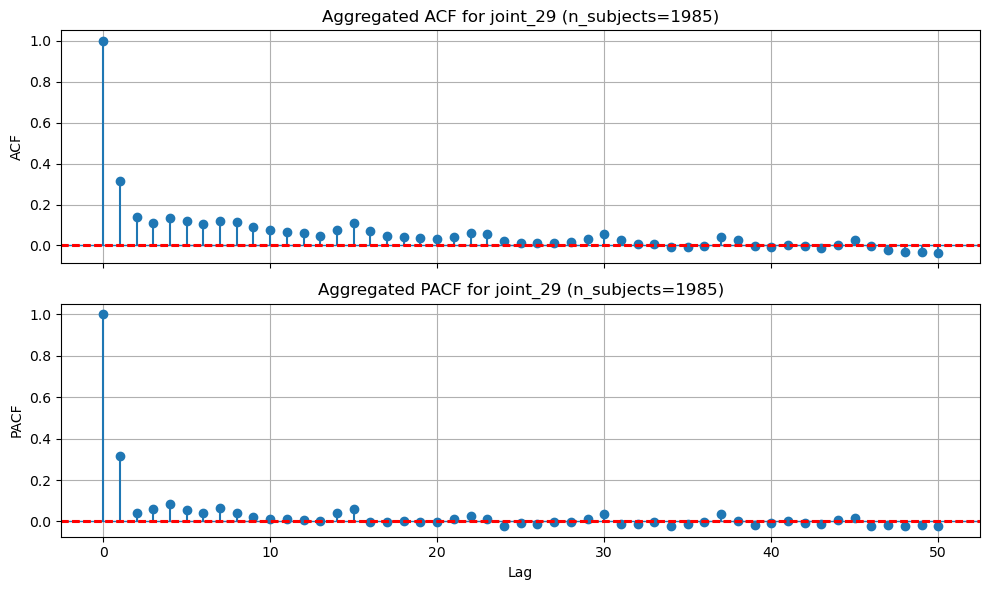


Processing column: pain_survey_1


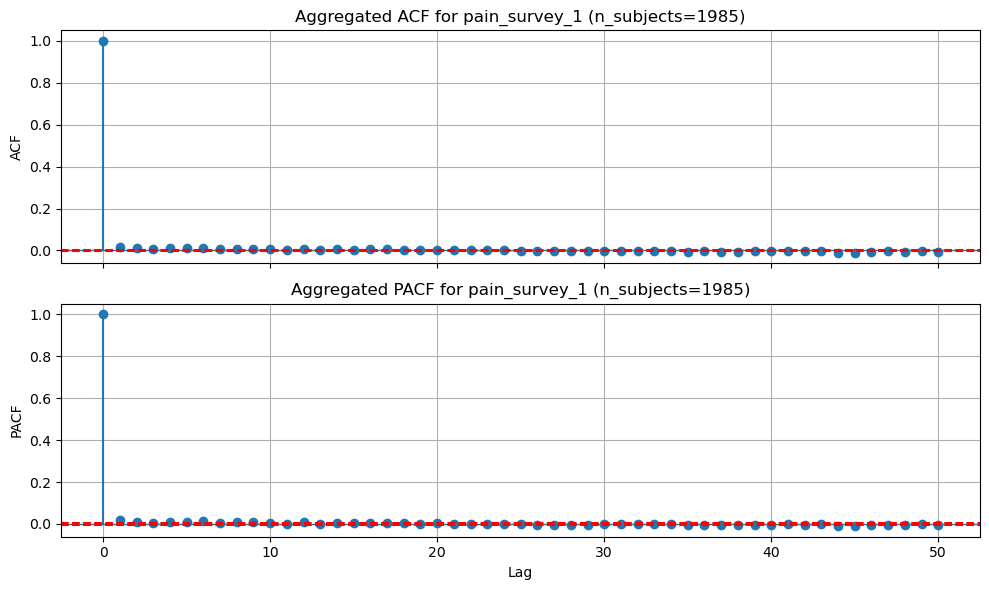


Processing column: pain_survey_2


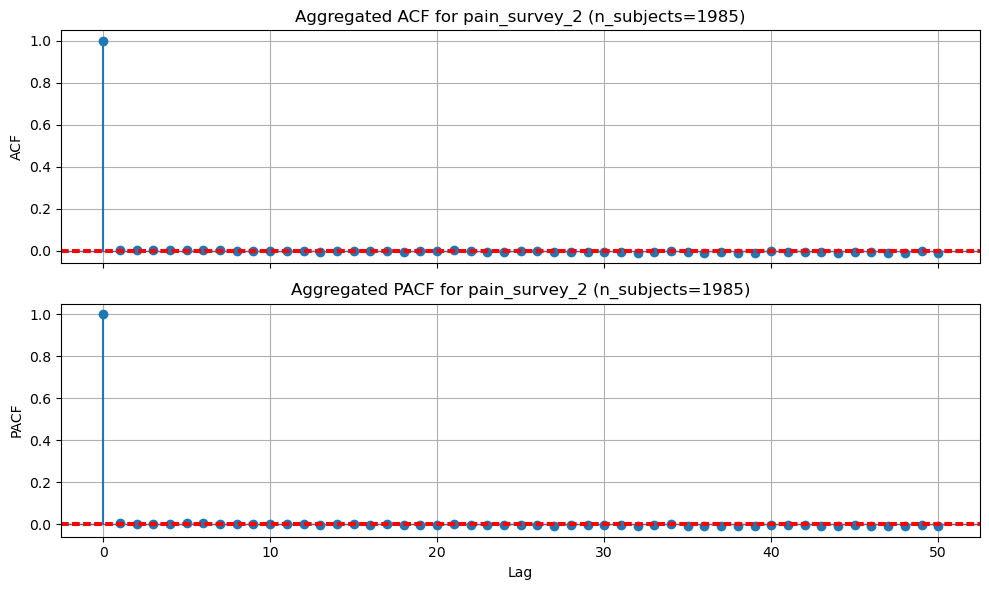


Processing column: pain_survey_3


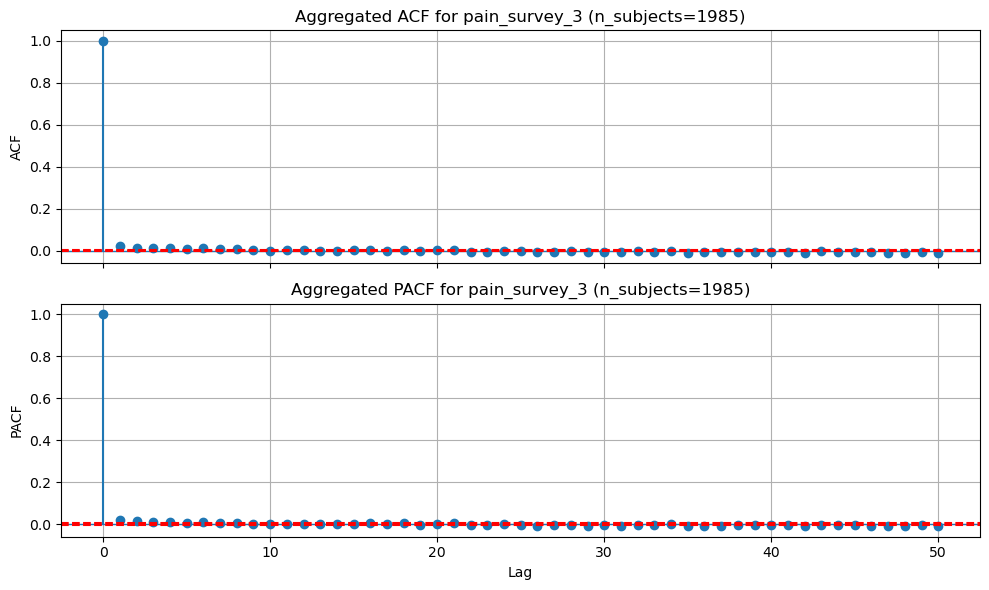


Processing column: pain_survey_4


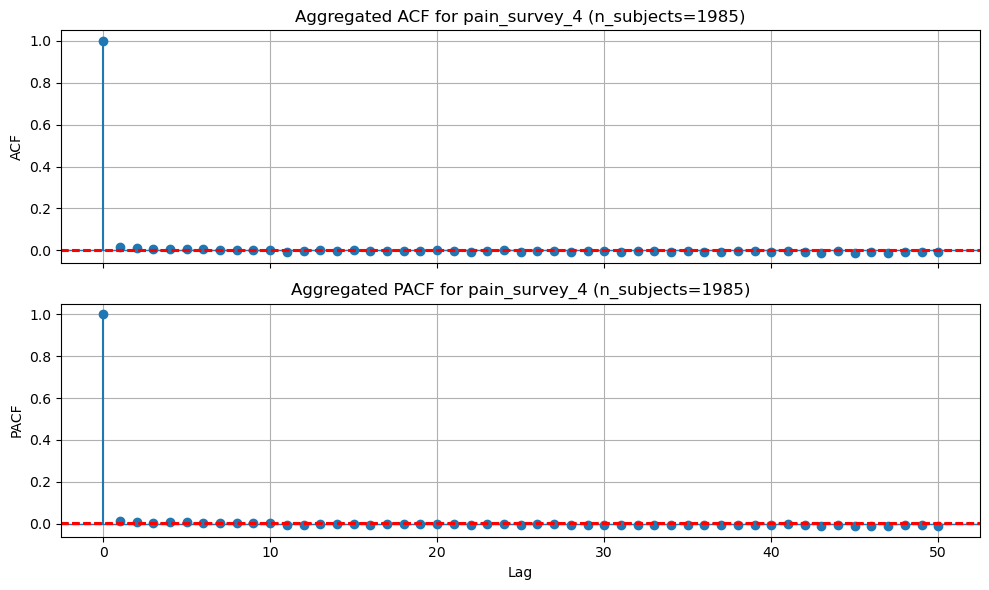

In [ ]:
# Configuration
MAX_LAG = 50       
MAX_SUBJECTS = None   # None to use all subjects

#diff_df = seasonal_diff_df(df_total, lag=1)
#diff_df = diff_df.dropna().reset_index(drop=True)

#diff_df = seasonal_diff_df(diff_df, lag=1)
#diff_df = diff_df.dropna().reset_index(drop=True)

for col in series_cols:
    print("\n==============================")
    print(f"Processing column: {col}")
    
    acf, pacf = pooled_acf_pacf_all(df_total[["sample_index", col]], col, max_lag=MAX_LAG)
    
    plot_aggregated_acf_pacf(np.arange(MAX_LAG + 1), acf, pacf, col_name=col, n_users=N_USERS)


In [ ]:
print(df_total[["sample_index", "joint_00"]][df_total["sample_index"] == 0].drop("sample_index", axis=1).values.flatten())

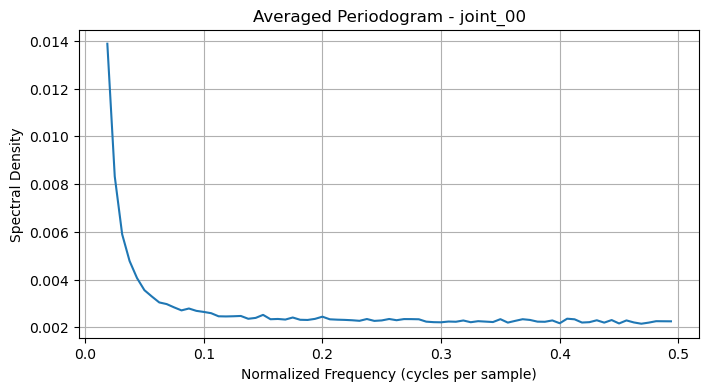

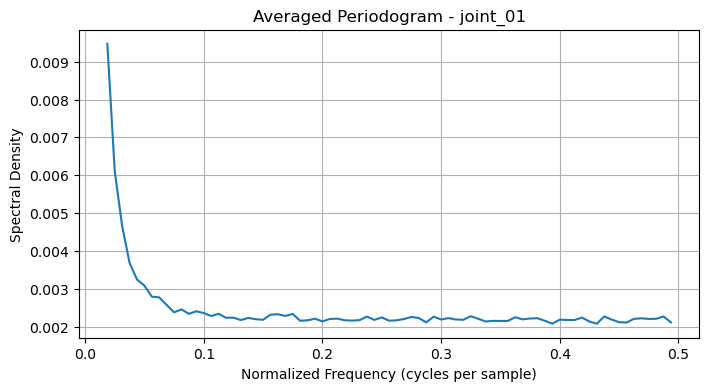

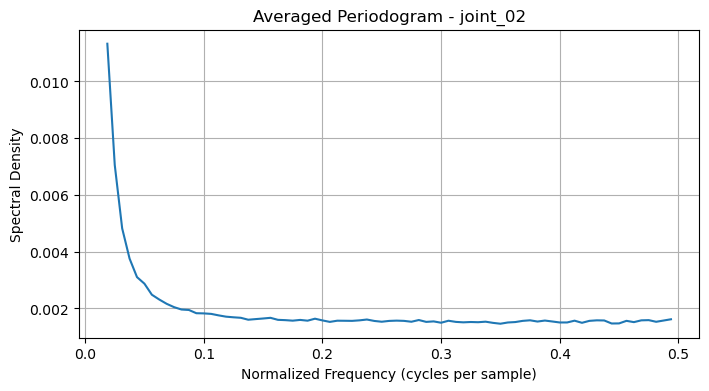

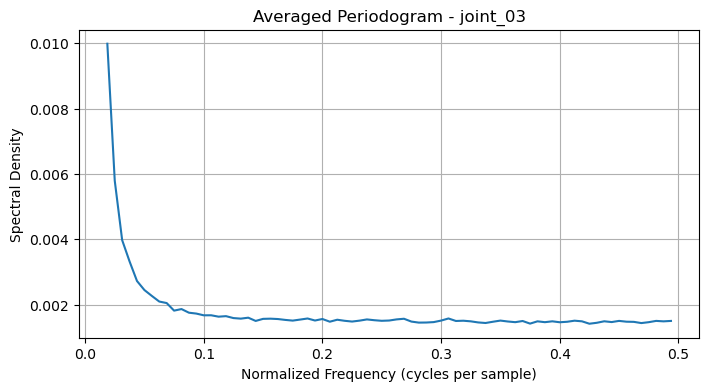

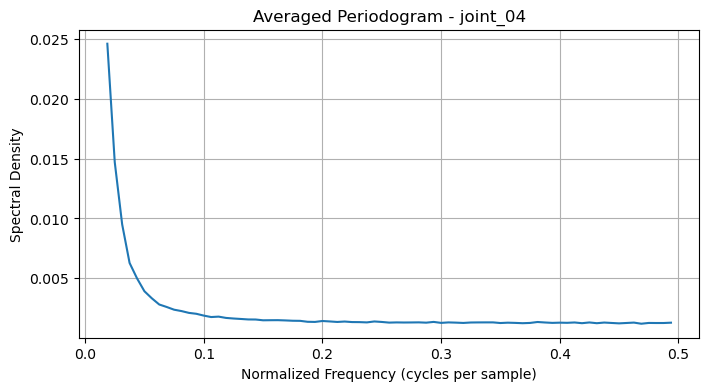

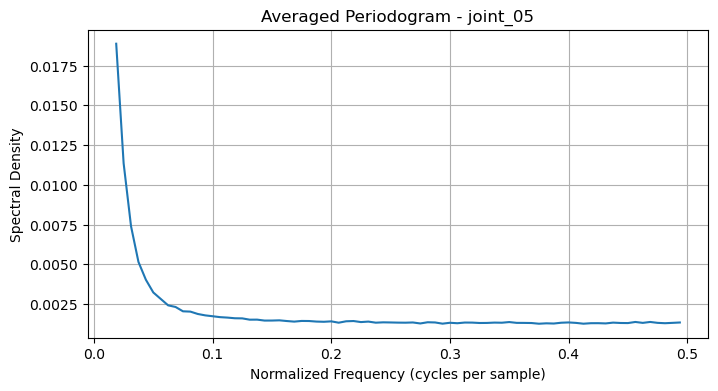

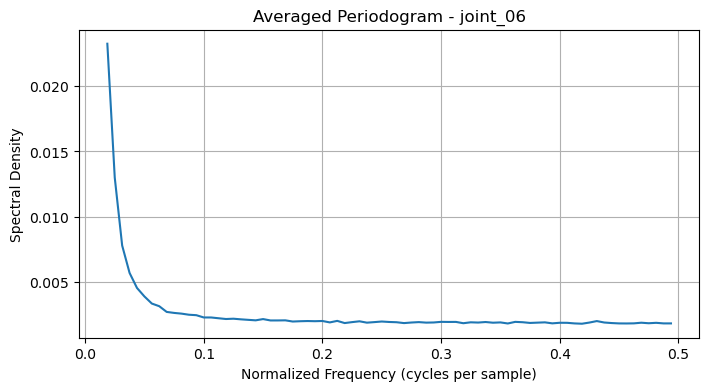

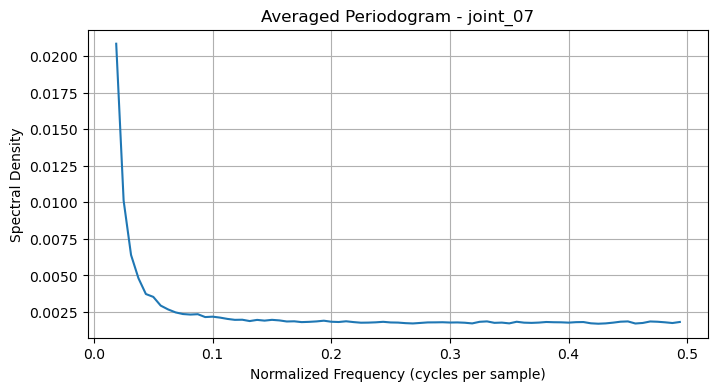

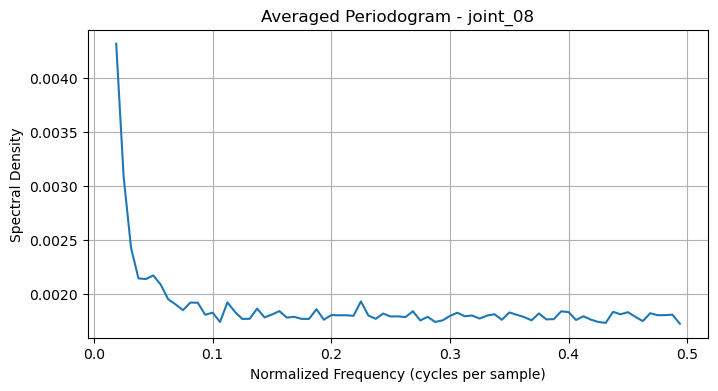

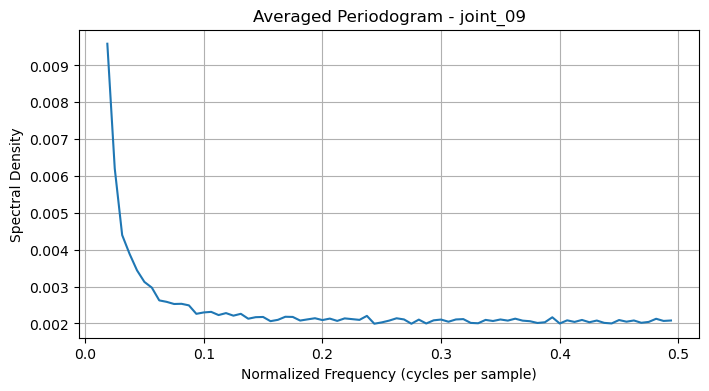

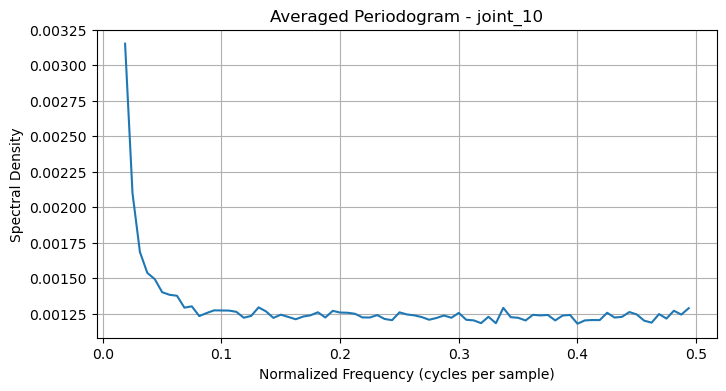

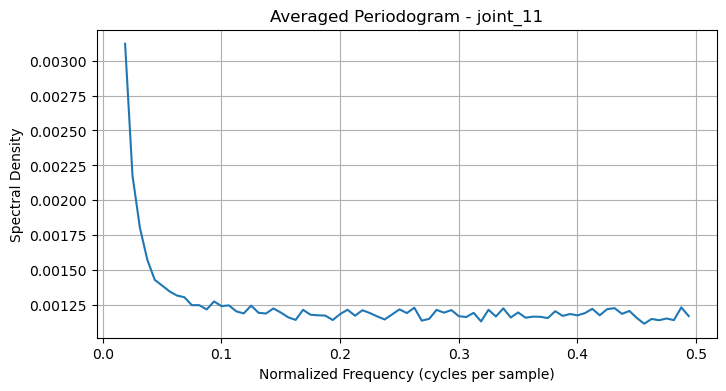

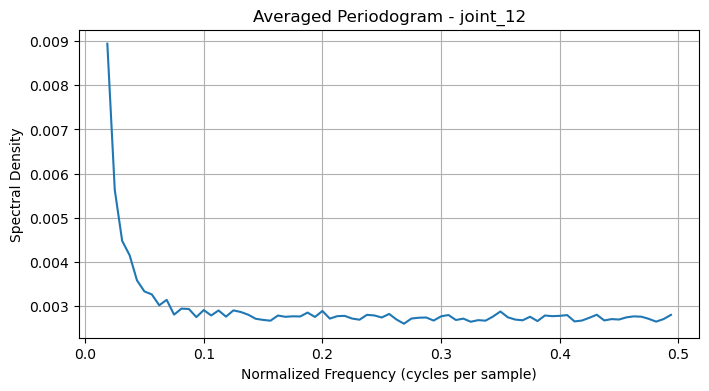

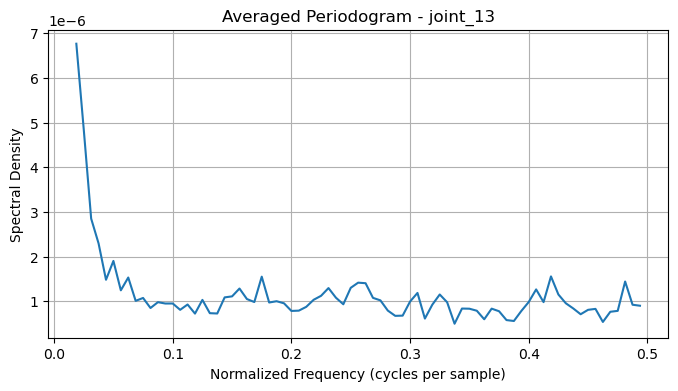

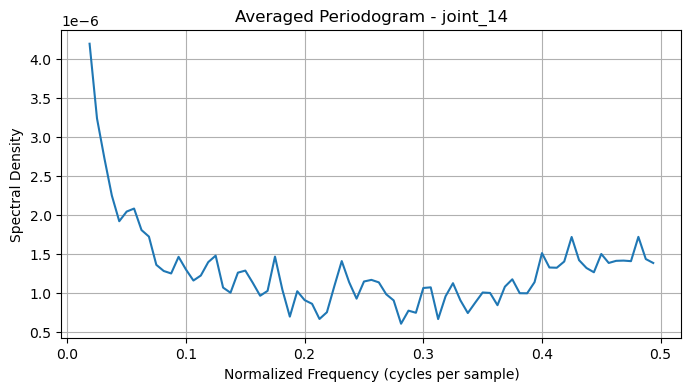

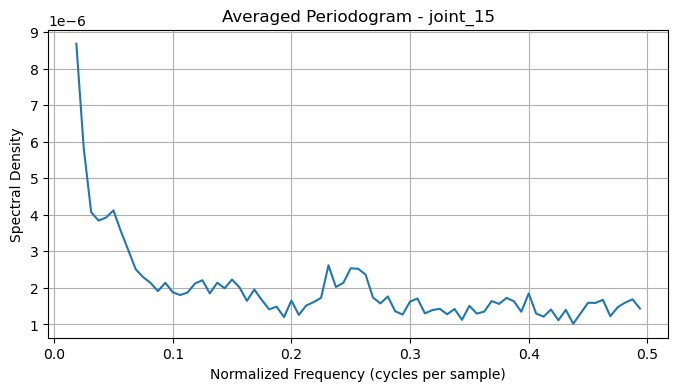

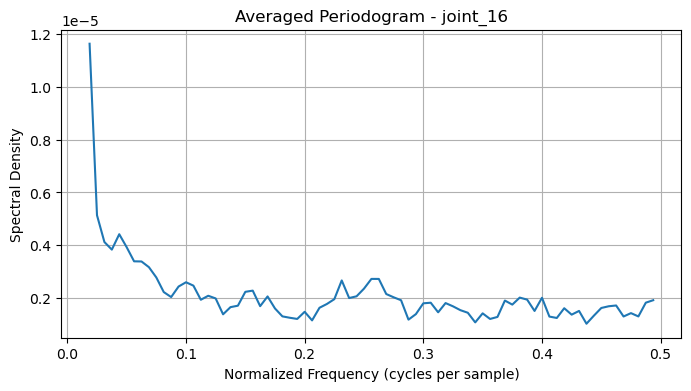

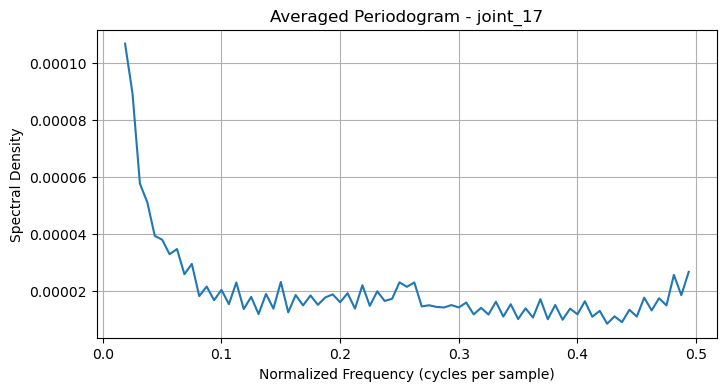

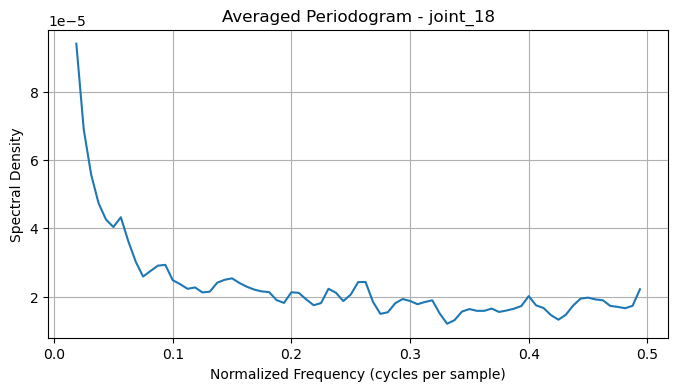

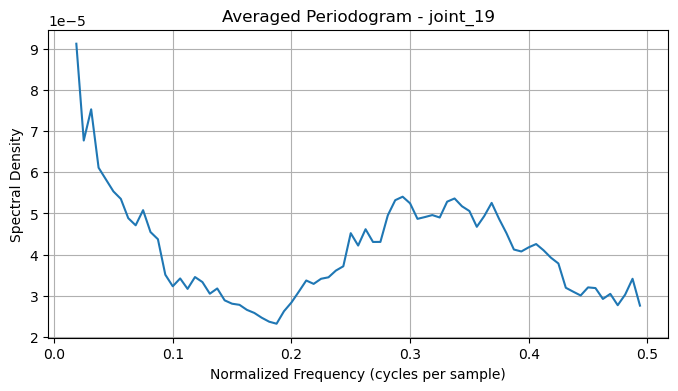

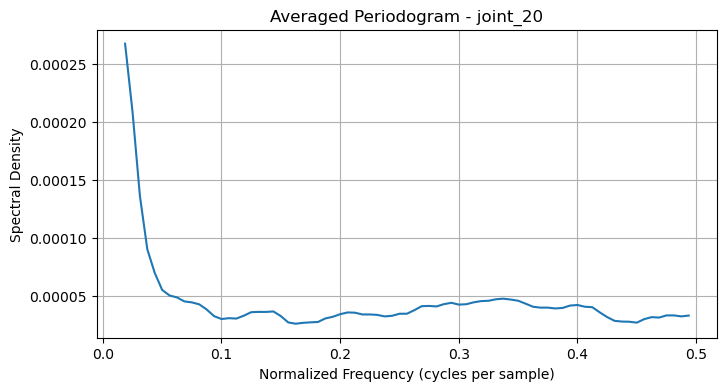

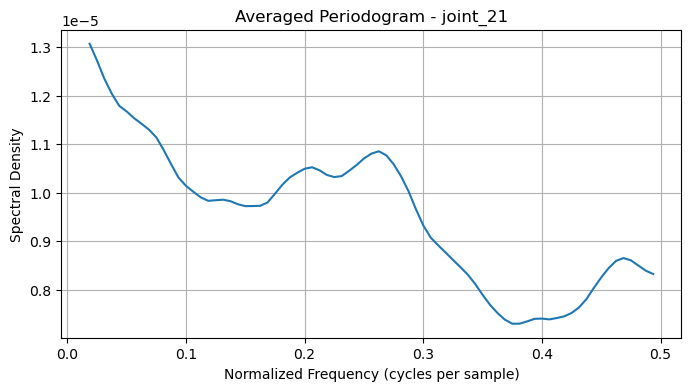

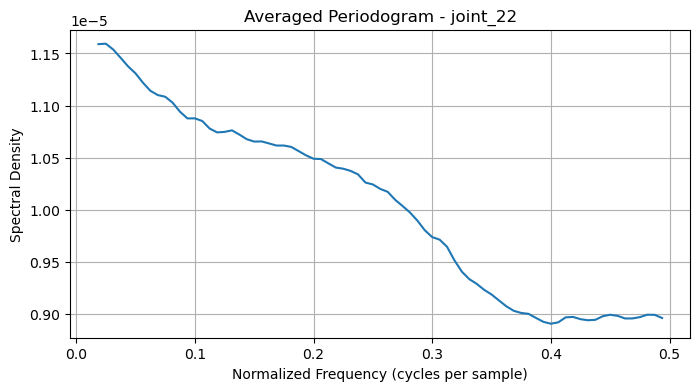

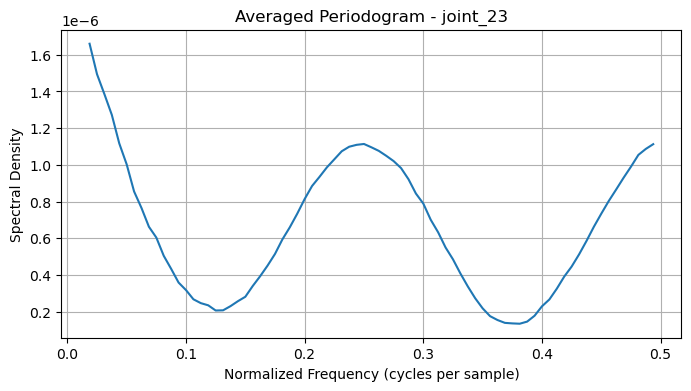

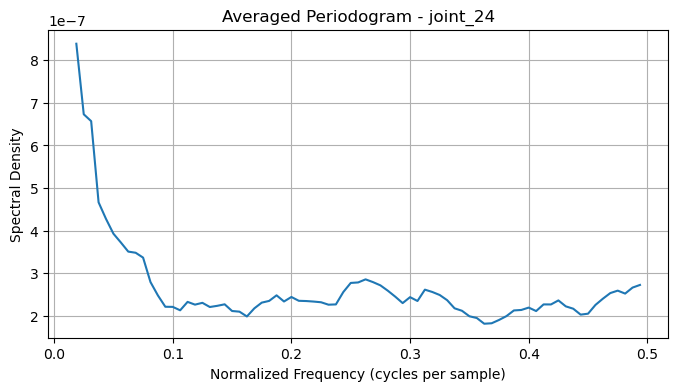

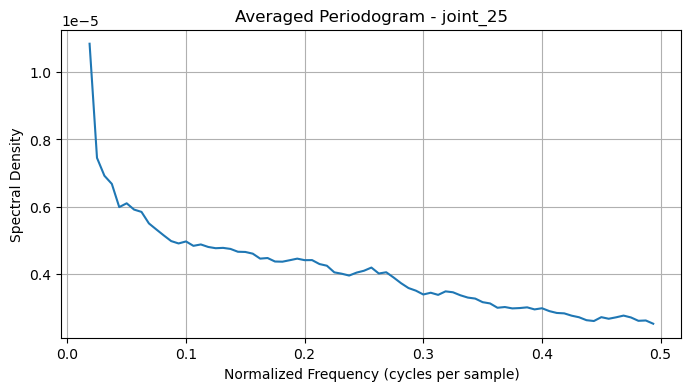

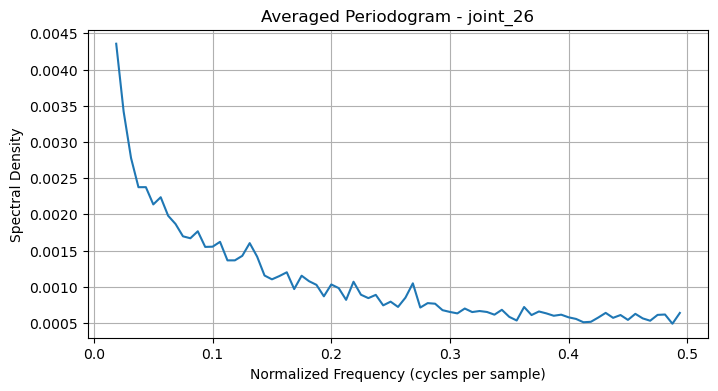

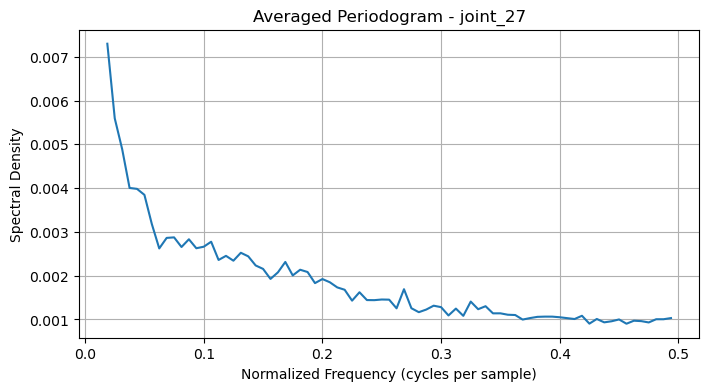

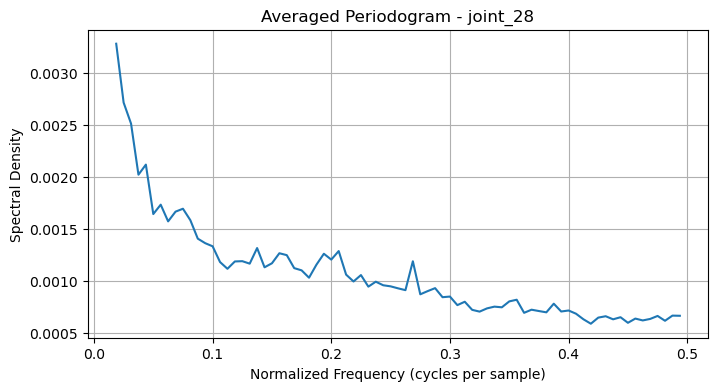

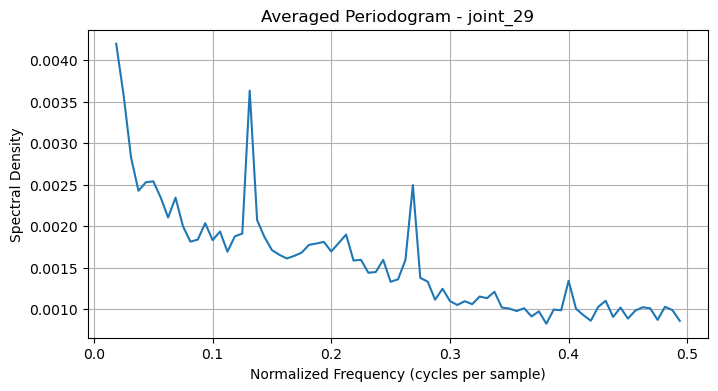

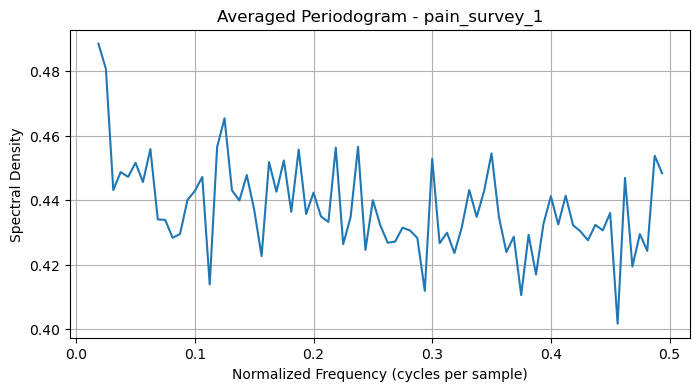

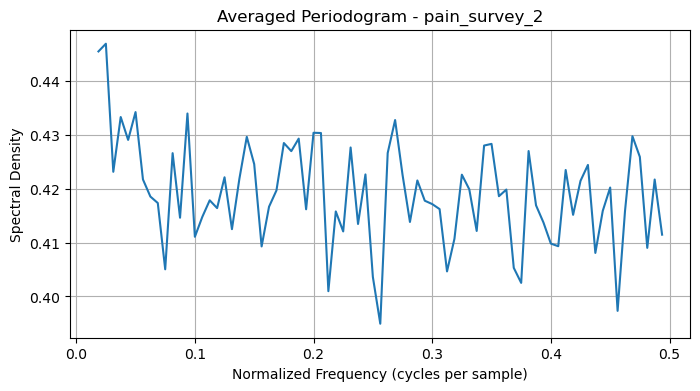

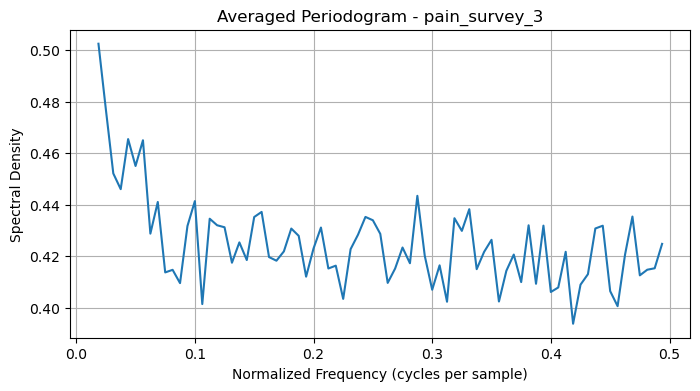

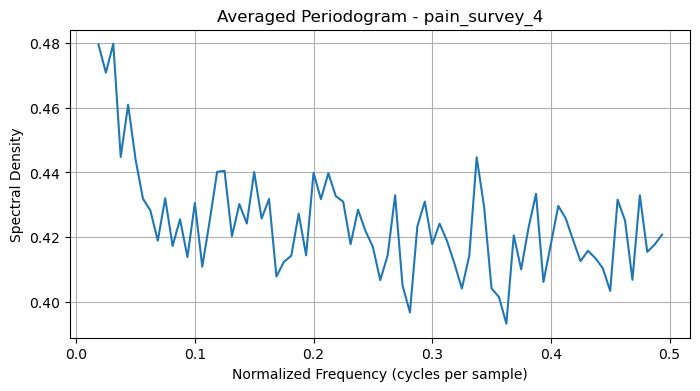

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Compute averaged periodogram per feature
def averaged_periodogram(feature_series, user_index):
    """
    feature_series: pd.Series (single feature, indexed by MultiIndex (user,timestamp))
    user_index: list of unique users
    """
    N = 160
    
    periodograms = []
    
    for user in user_index:
        ts = feature_series[feature_series["sample_index"] == user].drop("sample_index", axis=1).values.flatten()  # get time series for this user
        fft_vals = np.fft.fft(ts, N)
        periodogram = (np.abs(fft_vals)**2)/N
        periodograms.append(periodogram[3:N//2])  # positive frequencies
    
    periodograms = np.array(periodograms)
    avg_periodogram = periodograms.mean(axis=0)
    
    freqs = np.fft.fftfreq(N)[3:N//2]
    return freqs, avg_periodogram

# Compute periodograms for all features
feature_periodograms = {}

for col in series_cols:
    freqs, avg_periodogram = averaged_periodogram(df_total[["sample_index", col]], df_total['sample_index'].unique())
    feature_periodograms[col] = (freqs, avg_periodogram)
    
    # Plot
    plt.figure(figsize=(8,4))
    plt.plot(freqs, avg_periodogram)
    plt.title(f"Averaged Periodogram - {col}")
    plt.xlabel("Normalized Frequency (cycles per sample)")
    plt.ylabel("Spectral Density")
    plt.show()